In [80]:
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append('../')

from model.inference import get_model
from configs import TrainConfig, PatchFMConfig, EvalConfig

In [84]:
model_cfg = PatchFMConfig(normalization_strategy='causal', use_asinh=True, prefix_tokens=4)
train_cfg = TrainConfig(checkpoint_path='../ckpts/')
eval_cfg = EvalConfig()

model = get_model(model_cfg, train_cfg, eval_cfg)

Loading PatchFM with normalization strategy: causal and use_asinh: True
Loading model from ../ckpts/causalsinh/patchfm-epoch=18.ckpt...
Model loaded successfully from ../ckpts/causalsinh/patchfm-epoch=18.ckpt.


In [85]:
context = 512
target_size = 128
xx = torch.linspace(0, 1, context + target_size).unsqueeze(0) + torch.randn(1, context + target_size) * 0.001
sinus = torch.sin(2 * torch.pi * xx * 10)
context_data = sinus[:, :context]
target_data = sinus[:, context:]

points_forecast, quantiles = model.forecast(context_data, target_size)

Text(0, 0.5, 'Value')

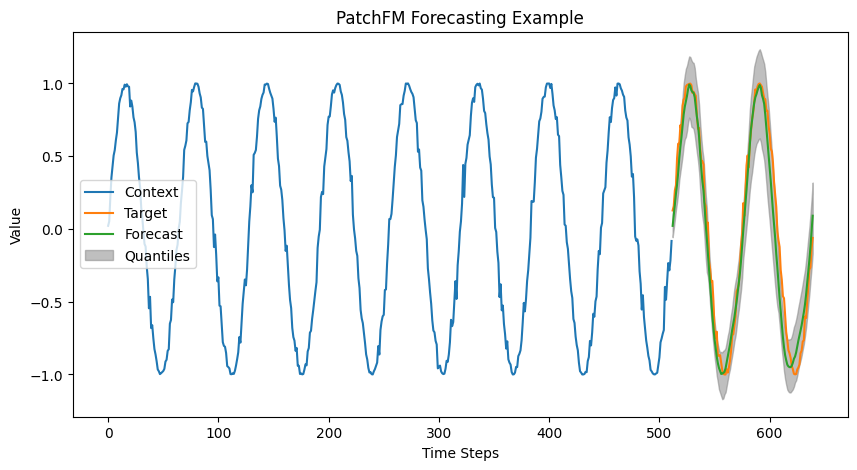

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(range(context), context_data.squeeze().numpy(), label='Context')
plt.plot(range(context, context + target_size), target_data.squeeze().numpy(), label='Target')
plt.plot(range(context, context + target_size), points_forecast.squeeze().numpy(), label='Forecast')
plt.fill_between(range(context, context + target_size), quantiles[0, :, 0].squeeze().numpy(), quantiles[0, :, -1].squeeze().numpy(), color='gray', alpha=0.5, label='Quantiles')
plt.legend()
plt.title('PatchFM Forecasting Example')
plt.xlabel('Time Steps')
plt.ylabel('Value')